# IMC-Denoise: a content aware denoising pipeline to enhance imaging mass cytometry

Here we will show an example for denoising the images with marker CD14 from our own human bone marrow IMC dataset. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tp
from IMC_Denoise.IMC_Denoise_main.DIMR import DIMR
from IMC_Denoise.IMC_Denoise_main.DeepSNiF import DeepSNiF


In [2]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


### Load the pre-trained denoisng model for a marker

In [5]:
channel_name = "B7-H4"
weights_name = "weights_"+channel_name+".hdf5" # trained network weights name. 
weights_save_directory = None # location where 'weights_name' will be loaded. 
# If the value is None, the files will be loaded from the default directory.
is_load_weights = True # read from the saved one.
deepsnif = DeepSNiF(weights_name = weights_name,
                  weights_dir = weights_save_directory, 
                  is_load_weights = is_load_weights)

Pre-trained model /home/giuseppe/devices/Delta_Tissue/IMC/IMC_Denoise/application_results/trained_weights/weights_B7-H4.hdf5 loaded successfully.
Pre-calculated range value file /home/giuseppe/devices/Delta_Tissue/IMC/IMC_Denoise/application_results/trained_weights/weights_B7-H4_range_val.npz loaded successfully.


### Load a raw CD14 image

Text(0.5, 1.0, '10% scale')

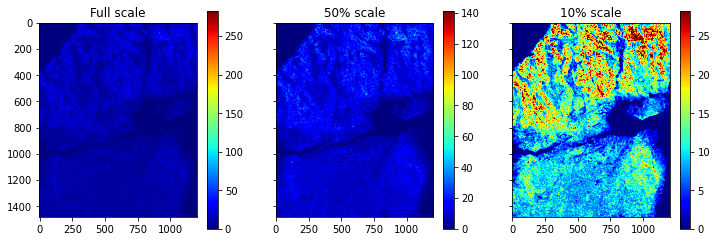

In [7]:
# read a CD14 raw image.
Raw_img_name = "/home/giuseppe/devices/Delta_Tissue/IMC/split_channels_nohpf/Leap042_6/"+channel_name+'.tiff' # change to your raw image name
Img_raw = tp.imread(Raw_img_name)

f,ax = plt.subplots(ncols=3,figsize = (12,4),sharey=True)
hm = ax[0].imshow(Img_raw, vmin = 0, vmax = np.max(Img_raw), cmap = 'jet')
plt.colorbar(hm,ax=ax[0])
ax[0].set_title('Full scale')
hm = ax[1].imshow(Img_raw, vmin = 0, vmax = 0.5*np.max(Img_raw), cmap = 'jet')
plt.colorbar(hm,ax=ax[1])
ax[1].set_title('50% scale')
hm = ax[2].imshow(Img_raw, vmin = 0, vmax = 0.1*np.max(Img_raw), cmap = 'jet')
plt.colorbar(hm,ax=ax[2])
ax[2].set_title('10% scale')
#plt.savefig('figures/many_contrast_raw.png')
#plt.show()

### Perform the DIMR algorithm only if the SNR of the raw image is high.

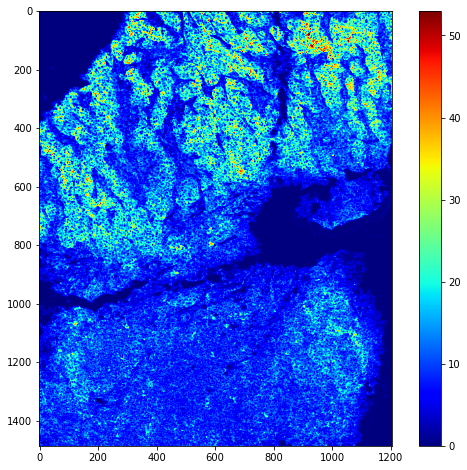

In [8]:
n_neighbours = 20 # 10 Larger n enables removing more consecutive hot pixels. 
n_iter = 3 # Iteration number for DIMR
window_size = 5 # Slide window size. For IMC images, window_size = 3 is fine.
Img_DIMR = DIMR(n_neighbours = n_neighbours, n_iter = n_iter, window_size = window_size).perform_DIMR(Img_raw)
plt.figure(figsize = (10,8))
plt.imshow(Img_DIMR, vmin = 0, vmax = 0.5*np.max(Img_DIMR), cmap = 'jet')
plt.colorbar()
plt.show()

[]

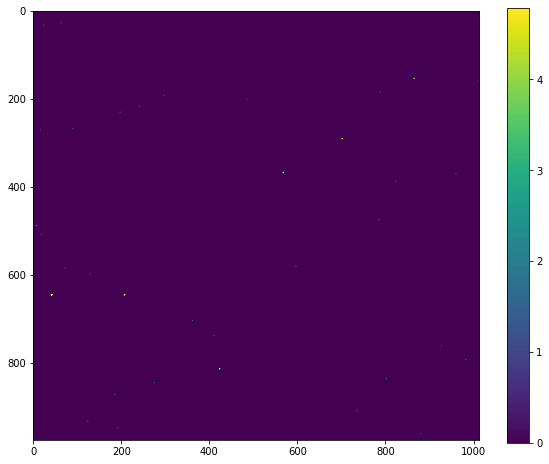

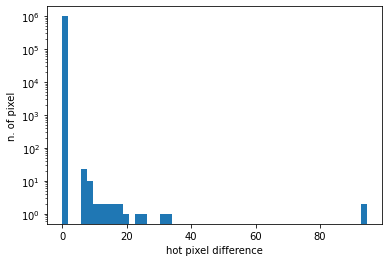

In [33]:
plt.figure(figsize = (10,8))
plt.imshow(Img_raw-Img_DIMR,vmax = Img_DIMR.max()/2)
plt.colorbar()
np.max(Img_raw),np.max(Img_DIMR)
plt.figure()
plt.hist(np.abs(Img_raw-Img_DIMR).reshape(-1),50)
plt.ylabel('n. of pixel')
plt.xlabel('hot pixel difference')
plt.semilogy()
#plt.savefig('figures/pixel_difference_highthr.png')

### If the SNR of the raw image is sub-optimal, perform DIMR and DeepSNiF algorithms for low SNR raw images.
If errors happen, check if the GPUs are being used by other sessions. If yes, shutdown the session occupying GPUs and re-run the prediction.

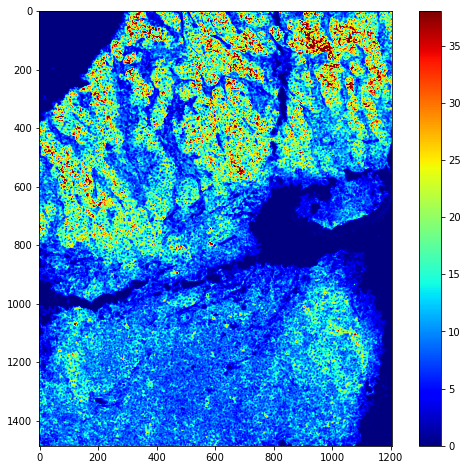

In [10]:
# perform DIMR and DeepSNiF algorithms for low SNR raw images.
Img_DIMR_DeepSNiF = deepsnif.perform_IMC_Denoise(Img_raw, n_neighbours = n_neighbours, n_iter = n_iter, window_size = window_size)
plt.figure(figsize = (10,8))
plt.imshow(Img_DIMR_DeepSNiF, vmin = 0, vmax = 0.5*np.max(Img_DIMR_DeepSNiF), cmap = 'jet')
plt.colorbar()
plt.show()

Text(0.5, 0, 'pixel difference [raw-processed]')

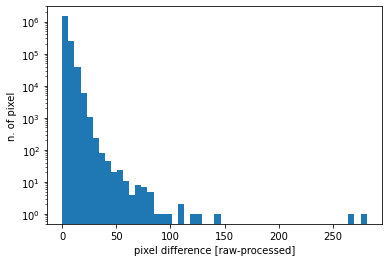

In [6]:
plt.hist(np.abs(Img_raw-Img_DIMR_DeepSNiF).reshape(-1),50)
plt.semilogy()
plt.ylabel('n. of pixel')
plt.xlabel('pixel difference [raw-processed]')
#plt.savefig('figures/pixel_difference2.png')

## Compare to hpf that it was

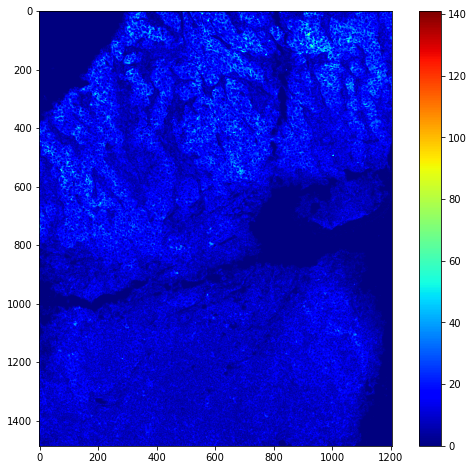

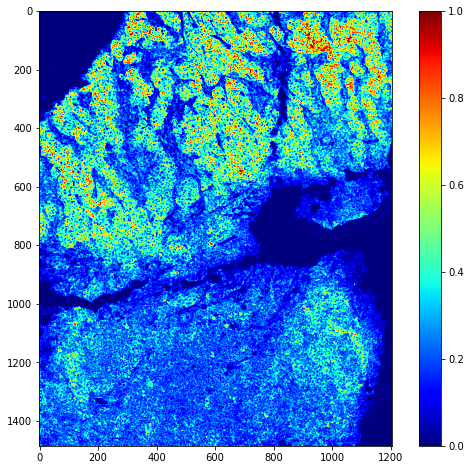

In [55]:
hpf_img_name = Raw_img_name.replace('_nohpf','') # change to your raw image name
Img_hpf = tp.imread(hpf_img_name)
plt.figure(figsize = (10,8))
plt.imshow(Img_hpf, vmin = 0, vmax = 0.5*np.max(Img_raw), cmap = 'jet')
plt.colorbar()
plt.figure(figsize = (10,8))
q = np.quantile(Img_raw.reshape(-1),0.99)
a = Img_raw/q
a[a>1]=1
plt.imshow(a, vmin = 0, vmax = np.max(a), cmap = 'jet')
plt.colorbar()

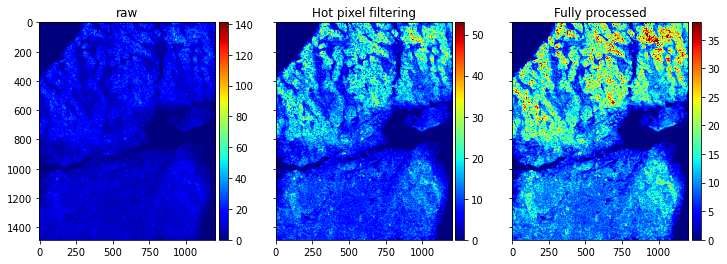

In [58]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(nrows=1, ncols=3,figsize =(12,4) ,sharey=True)

im1 = ax[0].imshow(Img_raw, vmin = 0, vmax = 0.5*np.max(Img_raw), cmap = 'jet')
divider = make_axes_locatable(ax[0])
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im1, cax=cax, orientation='vertical')
ax[0].set_title('raw')

im2 = ax[1].imshow(Img_DIMR, vmin = 0, vmax = 0.5*np.max(Img_DIMR), cmap = 'jet')
divider = make_axes_locatable(ax[1])
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im2, cax=cax, orientation='vertical')
ax[1].set_title('Hot pixel filtering')

ax[2].set_title('Fully processed')
im3 = ax[2].imshow(Img_DIMR_DeepSNiF, vmin = 0, vmax = 0.5*np.max(Img_DIMR_DeepSNiF), cmap = 'jet')
divider = make_axes_locatable(ax[2])
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im3, cax=cax, orientation='vertical')
#plt.savefig('figures/comparison.png')

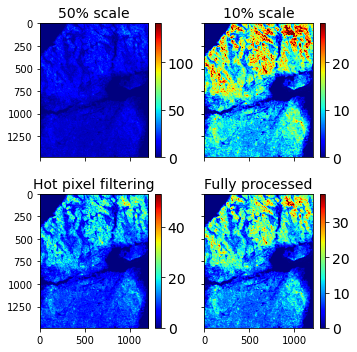

In [142]:
f,ax = plt.subplots(ncols=2,nrows=2,figsize = (5,5),sharey=True,sharex = True)

hm = ax[0,0].imshow(Img_raw, vmin = 0, vmax = 0.5*np.max(Img_raw), cmap = 'jet')
divider = make_axes_locatable(ax[0,0])
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = fig.colorbar(hm, cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=14)

ax[0,0].set_title('50% scale',fontsize = 14)
hm = ax[0,1].imshow(Img_raw, vmin = 0, vmax = 0.1*np.max(Img_raw), cmap = 'jet')
divider = make_axes_locatable(ax[0,1])
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = fig.colorbar(hm, cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=14)

ax[0,1].set_title('10% scale',fontsize = 14)
im2 = ax[1,0].imshow(Img_DIMR, vmin = 0, vmax = 0.5*np.max(Img_DIMR), cmap = 'jet')
divider = make_axes_locatable(ax[1,0])
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = fig.colorbar(im2, cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=14)
ax[1,0].set_title('Hot pixel filtering',fontsize = 14)

ax[1,1].set_title('Fully processed',fontsize = 14)
im3 = ax[1,1].imshow(Img_DIMR_DeepSNiF, vmin = 0, vmax = 0.5*np.max(Img_DIMR_DeepSNiF), cmap = 'jet')
divider = make_axes_locatable(ax[1,1])
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = fig.colorbar(im3, cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=14) 
plt.tight_layout()
#plt.savefig('figures/comparison_all.png')

In [133]:
help(ax[0,0].set_aspect)

Help on method set_aspect in module matplotlib.axes._base:

set_aspect(aspect, adjustable=None, anchor=None, share=False) method of matplotlib.axes._subplots.AxesSubplot instance
    Set the aspect of the axis scaling, i.e. the ratio of y-unit to x-unit.
    
    Parameters
    ----------
    aspect : {'auto'} or num
        Possible values:
    
        ========   =================================================
        value      description
        ========   =================================================
        'auto'     automatic; fill the position rectangle with data.
        num        a circle will be stretched such that the height
                   is *num* times the width.  'equal' is a synonym
                   for ``aspect=1``, i.e. same scaling for x and y.
        ========   =================================================
    
    adjustable : None or {'box', 'datalim'}, optional
        If not ``None``, this defines which parameter will be adjusted to
        m

In [15]:
import sklearn
sklearn.__version__

'0.24.2'

In [1]:
import matplotlib.pyplot as plt

In [17]:
Raw_img_name.replace('_nohpf','')

'/home/giuseppe/devices/Delta_Tissue/IMC/split_channels/Leap042_6/CD8a.tiff'

In [12]:
import tensorflow as tf

In [32]:
tf.keras.utils.save_img('figures/'+channel_name+'_Leap042_6.tiff',np.expand_dims(Img_DIMR_DeepSNiF,axis = 0),scale = False,data_format="channels_first")

(array([1.085337e+06, 5.014930e+05, 1.479270e+05, 3.983900e+04,
        1.002100e+04, 2.333000e+03, 5.470000e+02, 1.200000e+02,
        3.000000e+01, 1.100000e+01]),
 array([2.9802322e-08, 1.0597289e+01, 2.1194578e+01, 3.1791868e+01,
        4.2389156e+01, 5.2986446e+01, 6.3583736e+01, 7.4181023e+01,
        8.4778313e+01, 9.5375603e+01, 1.0597289e+02], dtype=float32),
 <BarContainer object of 10 artists>)

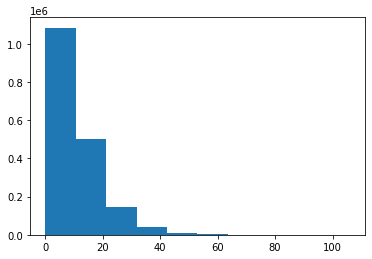

In [13]:
plt.hist(Img_DIMR.reshape(-1))

(array([9.83035e+05, 5.44300e+03, 1.04000e+02, 2.50000e+01, 1.80000e+01,
        1.00000e+01, 6.00000e+00, 4.00000e+00, 1.00000e+00, 4.00000e+00]),
 array([0.17065397, 1.1473575 , 2.1240609 , 3.1007645 , 4.077468  ,
        5.0541716 , 6.0308747 , 7.0075784 , 7.984282  , 8.960985  ,
        9.937689  ], dtype=float32),
 <BarContainer object of 10 artists>)

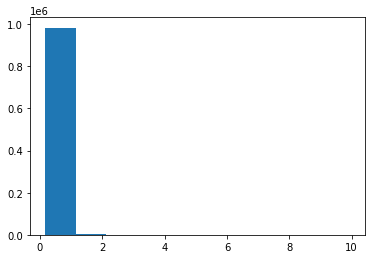

In [38]:
a = tp.imread('../../Img_Denoised/Leap002_4/Carboplatin.tiff')
plt.hist(a.reshape(-1))

In [9]:
img

NameError: name 'img' is not defined

In [3]:

import numpy as np
import time
import gc
import os

import argparse
from os import listdir
from os.path import isfile, join, abspath, exists
from glob import glob
import tifffile as tp

Raw_directory = "/home/giuseppe/devices/Delta_Tissue/IMC/split_channels_nohpf/"

# Load one acquisition directory
acquisition_dirs = [d for d in os.listdir(Raw_directory) if os.path.isdir(os.path.join(Raw_directory, d))]

if acquisition_dirs:
    # Take the first directory in the list
    first_acq_dir = os.path.join(Raw_directory, acquisition_dirs[0])
    
    # Get a list of markers by removing the file extension from files in the first directory
    marker_list = [os.path.splitext(file)[0] for file in os.listdir(first_acq_dir) if file.endswith('.tiff')]
else:
    raise ValueError('No file found in '+Raw_directory)
save_directory = '/home/giuseppe/devices/Delta_Tissue/IMC/Img_Denoised'
isExist = os.path.exists(save_directory)
if not isExist:
    os.makedirs(save_directory)
n_neighbours = 10 # Larger n enables removing more consecutive hot pixels. 
n_iter = 3 # Iteration number for DIMR
window_size = 5
channel_name = marker_list[0]
weights_name = "weights_"+channel_name+".hdf5" # trained network weights name. 
weights_save_directory = None # location where 'weights_name' will be loaded. 
Max_row_num = 0
Max_col_num = 0
Image_collect = []
Img_folders = glob(join(Raw_directory, "*", ""))

# define a class to save image information
class single_img_info:
    def __init__(self, Img = None, Sub_folder = None, Img_name = None, Pad_dims = None):
        self.Img = Img
        self.Sub_folder = Sub_folder
        self.Img_name = Img_name
        self.Pad_dims = Pad_dims


In [4]:
for Sub_img_folder in Img_folders:
    Img_list = [f for f in listdir(Sub_img_folder) if isfile(join(Sub_img_folder, f)) & (f.endswith(".tiff") or f.endswith(".tif"))]
    for Img_file in Img_list:
        if channel_name.lower() == os.path.splitext(Img_file)[0].lower():#strip extension to file and check it matches with marker
            Img_read = tp.imread(Sub_img_folder + Img_file).astype('float32')
            Image_collect.append(single_img_info(Img_read, Sub_img_folder, Img_file))
            Rows, Cols = np.shape(Img_read)
            Max_row_num = max(Max_row_num, Rows)
            Max_col_num = max(Max_col_num, Cols)
            break
            

In [5]:
import numpy as np
import time
import gc
import os

import argparse
from os import listdir
from os.path import isfile, join, abspath, exists
from glob import glob
import tifffile as tp
from tensorflow.keras import optimizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from IMC_Denoise.IMC_Denoise_main.DeepSNiF_model import DeepSNiF_net, DeepSNiF_net_small
from IMC_Denoise.IMC_Denoise_main.loss_functions import create_I_divergence, create_mse
from IMC_Denoise.IMC_Denoise_main.DIMR import DIMR
from IMC_Denoise.Anscombe_transform.Anscombe_transform_functions import Anscombe_forward, Anscombe_inverse_exact_unbiased
input_ = Input (shape = (None, None, 1))
network_used = DeepSNiF_net_small


Max_row_num = int((Max_row_num//16+1)*16)
Max_col_num = int((Max_col_num//16+1)*16)

print('Loading model...')
weights_dir = weights_save_directory
if weights_dir is None:
    weights_dir = abspath('trained_weights')
trained_weights = join(weights_dir, weights_name)
print('The file containing the trained weights is {}.'.format(trained_weights))

myrange = np.load(join(weights_dir, weights_name.replace('.hdf5', '_range_val.npz'))) 
myrange = myrange['range_val']
print('The range is %f.' % myrange)

input_ = Input (shape = (None, None, 1))
loss_func = 'I_divergence'
act_ = network_used(input_, 'Pred_', loss_func = loss_func)
model = Model (inputs= input_, outputs=act_)
model.compile(optimizer = optimizers.Adam(lr=1e-3), loss = create_I_divergence(lambda_HF = 0))
model.load_weights(trained_weights)
print('Model loaded!')

Img_num = len(Image_collect)
All_img_read = np.zeros((Img_num, Max_row_num, Max_col_num, 1))
def split_border(length):
    half_length = int(length/2)
    if length%2 == 0:
        return half_length, half_length
    else:
        return half_length, half_length + 1


Loading model...
The file containing the trained weights is /home/giuseppe/devices/Delta_Tissue/IMC/IMC_Denoise/application_results/trained_weights/weights_B7-H4.hdf5.
The range is 109.756689.
Model loaded!


/home/giuseppe/anaconda3/envs/IMC_Denoise/lib/python3.6/site-packages/keras/optimizer_v2/optimizer_v2.py:356: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  "The `lr` argument is deprecated, use `learning_rate` instead.")


In [6]:
for ii in range(Img_num):
    Cur_img = Image_collect[ii].Img
    Image_collect[ii].Img = None
    Rows, Cols = np.shape(Cur_img)
    
    Cur_img = np.divide(Cur_img, myrange)
    
    Rows_diff = Max_row_num - Rows
    Cols_diff = Max_col_num - Cols
    Rows_diff1, Rows_diff2 = split_border(Rows_diff)
    Cols_diff1, Cols_diff2 = split_border(Cols_diff)
        
    All_img_read[ii][:,:,0] = np.pad(Cur_img,((Rows_diff1,Rows_diff2),(Cols_diff1,Cols_diff2)),'edge')
    Image_collect[ii].Pad_dims = [Rows_diff1, Rows_diff2, Cols_diff1, Cols_diff2]


In [7]:
All_img_denoised = model.predict(All_img_read, batch_size = 1)

In [61]:
model.predict?

Signature:
model.predict(
    x,
    batch_size=None,
    verbose=0,
    steps=None,
    callbacks=None,
    max_queue_size=10,
    workers=1,
    use_multiprocessing=False,
)
Docstring:
Generates output predictions for the input samples.

Computation is done in batches. This method is designed for performance in
large scale inputs. For small amount of inputs that fit in one batch,
directly using `__call__` is recommended for faster execution, e.g.,
`model(x)`, or `model(x, training=False)` if you have layers such as
`tf.keras.layers.BatchNormalization` that behaves differently during
inference. Also, note the fact that test loss is not affected by
regularization layers like noise and dropout.

Args:
    x: Input samples. It could be:
      - A Numpy array (or array-like), or a list of arrays
        (in case the model has multiple inputs).
      - A TensorFlow tensor, or a list of tensors
        (in case the model has multiple inputs).
      - A `tf.data` dataset.
      - A generator

In [3]:
tf.__version__

'2.6.2'